In [1]:
# HIGH_COST Logit Model — CRSS 2023 (BINNED VERSION, NO WEATHER)
# Change requested: DROP "Unknown" vehicle age by dropping missing/invalid MOD_YEAR
# - Outcome HIGH_COST: (TOWED in {6,7}) OR (ROLLOVER==3) OR (FIRE_EXP==1) OR (DEFORMED==6)
# - Speed: median imputation, then SPEED_BIN (no SP_MISSING in the model)
# - Vehicle age: VEH_AGE = 2023 - MOD_YEAR, binned; rows with missing/invalid MOD_YEAR are dropped
# - Driver: AGE_BIN, SEX, UNBUCKLED (+ BELT_UNKNOWN), DRUGS (+ DRUGS_UNKNOWN)
# - Accident: NIGHT, LIGHT, REGION_USE, URBAN_USE, ALCOHOL (+ ALCOHOL_UNKNOWN)
# - Controls: BODY, P2, VSUR
# - Cluster-robust SE by crash (CASENUM)
#
# NOTE: statsmodels may warn about cluster cov with var_weights; we silence it.

import warnings
warnings.filterwarnings("ignore", message=".*cov_type.*var_weights.*")

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

# =========================================================
# 0) PATH + LOAD
# =========================================================
acc = pd.read_csv("accident.csv", low_memory=False)
veh = pd.read_csv("vehicle.csv",  low_memory=False)
per = pd.read_csv("person.csv",   low_memory=False)

# =========================================================
# helpers
# =========================================================
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def topn_other(series, topn):
    vc = series.value_counts(dropna=False)
    top = vc.head(topn).index
    return series.where(series.isin(top), "Other")

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def debug_find_cols(df, keywords):
    kw = tuple(k.lower() for k in keywords)
    return [c for c in df.columns if any(k in c.lower() for k in kw)]

# =========================================================
# 1) FIND REQUIRED COLUMNS (NO WEATHER)
# =========================================================
# --- accident.csv ---
hour_col   = pick_col(acc, ["HOUR_IM", "HOUR"])
light_col  = pick_col(acc, ["LGTCON_IMNAME", "LGT_CONDNAME", "LGT_COND_IMNAME", "LGT_COND"])
region_col = pick_col(acc, ["REGIONNAME", "REGION"])
urban_col  = pick_col(acc, ["URBANICITYNAME", "URBANICITY"])
alcohol_col = pick_col(acc, ["ALCOHOL_IM", "ALCOHOL_IMNAME", "ALCOHOL", "ALCOHOLNAME"])

for name, col in [("hour", hour_col), ("light", light_col), ("region", region_col),
                  ("urban", urban_col), ("alcohol", alcohol_col)]:
    if col is None:
        if name == "alcohol":
            print("accident.csv columns containing 'ALC':", debug_find_cols(acc, ["ALC", "ALCO"]))
        raise ValueError(f"accident.csv: cannot find column for '{name}'")

# --- vehicle.csv ---
vehno_col  = pick_col(veh, ["VEH_NO"])
trav_col   = pick_col(veh, ["TRAV_SP"])
p2_col     = pick_col(veh, ["P_CRASH2NAME", "P_CRASH2"])
vsur_col   = pick_col(veh, ["VSURCONDNAME", "VSURCOND"])
body_col   = pick_col(veh, ["ICFINALBODYNAME", "BODY_TYPNAME", "VPICBODYCLASSNAME", "BODY_TYP"])
modyr_col  = pick_col(veh, ["MOD_YEAR"])
w_col      = pick_col(veh, ["WEIGHT"])

towed_col  = pick_col(veh, ["TOWED"])
roll_col   = pick_col(veh, ["ROLLOVER"])
fire_col   = pick_col(veh, ["FIRE_EXP"])
deform_col = pick_col(veh, ["DEFORMED"])

for name, col in [("veh_no", vehno_col), ("trav_sp", trav_col), ("p_crash2", p2_col),
                  ("vsurcond", vsur_col), ("body", body_col), ("mod_year", modyr_col),
                  ("weight", w_col), ("towed", towed_col), ("rollover", roll_col),
                  ("fire", fire_col), ("deformed", deform_col)]:
    if col is None:
        raise ValueError(f"vehicle.csv: cannot find column for '{name}'")

# --- person.csv (drivers) ---
vehno_p  = pick_col(per, ["VEH_NO"])
pertyp   = pick_col(per, ["PER_TYP"])
age_col  = pick_col(per, ["AGE_IM", "AGE"])
sex_col  = pick_col(per, ["SEX_IMNAME", "SEXNAME", "SEX_IM", "SEX"])
rest_col = pick_col(per, ["RESTUSE_IMNAME", "REST_USE_IMNAME", "REST_USENAME", "RESTUSE"])
drugs_col = pick_col(per, ["DRUGS_IM", "DRUGS_IMNAME", "DRUGS", "DRUGSNAME"])

for name, col in [("veh_no", vehno_p), ("per_typ", pertyp), ("age", age_col),
                  ("sex", sex_col), ("rest", rest_col), ("drugs", drugs_col)]:
    if col is None:
        if name == "drugs":
            print("person.csv columns containing 'DRUG':", debug_find_cols(per, ["DRUG"]))
        raise ValueError(f"person.csv: cannot find column for '{name}'")

# =========================================================
# 2) VEHICLE-LEVEL BASE + HIGH_COST
# =========================================================
v = veh[[
    "CASENUM", vehno_col, trav_col, p2_col, vsur_col,
    body_col, modyr_col, w_col,
    towed_col, roll_col, fire_col, deform_col
]].copy()

v[vehno_col] = to_num(v[vehno_col])
v = v.dropna(subset=["CASENUM", vehno_col]).copy()

# weights
v["W"] = to_num(v[w_col])
v = v[v["W"].notna() & (v["W"] > 0)].copy()

# outcome flags (numeric codes)
v["TOWED_c"] = to_num(v[towed_col])
v["ROLL_c"]  = to_num(v[roll_col])
v["FIRE_c"]  = to_num(v[fire_col])
v["DEF_c"]   = to_num(v[deform_col])

# 2022+ towing commonly: 6=Towed, 7=Towed unknown reason
flag_towed  = v["TOWED_c"].isin([6, 7])
flag_roll   = v["ROLL_c"].eq(3)   # 2022+ rollover: 3=Rollover
flag_fire   = v["FIRE_c"].eq(1)   # fire: 1=Yes
flag_deform = v["DEF_c"].eq(6)    # deformed: 6=Disabling damage

v["HIGH_COST"] = (flag_towed | flag_roll | flag_fire | flag_deform).astype(int)

print(f"HIGH_COST rate (unweighted): {v['HIGH_COST'].mean():.3f}")
print(f"HIGH_COST=1: {v['HIGH_COST'].sum():,}  |  HIGH_COST=0: {(v['HIGH_COST']==0).sum():,}")

# =========================================================
# 3) SPEED: build TRAV_SP_REAL and impute median (for binning)
# =========================================================
v["TRAV_SP_RAW"]  = to_num(v[trav_col])
v["TRAV_SP_REAL"] = np.where(
    (v["TRAV_SP_RAW"] >= 1) & (v["TRAV_SP_RAW"] <= 151),
    v["TRAV_SP_RAW"],
    np.nan
)
median_sp = v["TRAV_SP_REAL"].median()
v["TRAV_SP_REAL"] = v["TRAV_SP_REAL"].fillna(median_sp)

print("\nSpeed imputation:")
print(f"  Median speed used for imputation: {median_sp:.1f} mph")

# =========================================================
# 4) VEHICLE COVARIATES
# =========================================================
v["P2"]       = v[p2_col].fillna("Unknown").astype("object")
v["VSUR"]     = v[vsur_col].fillna("Unknown").astype("object")
v["BODY"]     = v[body_col].fillna("Unknown").astype("object")
v["MOD_YEAR"] = to_num(v[modyr_col])

# =========================================================
# 5) CRASH-LEVEL (accident.csv): NIGHT/LIGHT/REGION/URBAN + ALCOHOL
# =========================================================
a = acc[["CASENUM", hour_col, light_col, region_col, urban_col, alcohol_col]].copy()
a[hour_col] = to_num(a[hour_col])
a["NIGHT"]  = ((a[hour_col] >= 20) | (a[hour_col] <= 5)).astype(int)

a = a.rename(columns={
    light_col:  "LIGHT",
    region_col: "REGION_USE",
    urban_col:  "URBAN_USE",
})

# ALCOHOL codes (2016+): 1=yes, 2=no, 8=n/a, 9=unknown
alc_num = to_num(a[alcohol_col])
a["ALCOHOL_INV"] = np.where(alc_num == 1, 1,
                     np.where(alc_num == 2, 0, np.nan))
a["ALCOHOL_UNKNOWN"] = a["ALCOHOL_INV"].isna().astype(int)
a["ALCOHOL_INV"] = a["ALCOHOL_INV"].fillna(0).astype(int)

for c in ["LIGHT", "REGION_USE", "URBAN_USE"]:
    a[c] = a[c].fillna("Unknown").astype("object")

a = a[["CASENUM", "NIGHT", "LIGHT", "REGION_USE", "URBAN_USE", "ALCOHOL_INV", "ALCOHOL_UNKNOWN"]].drop_duplicates("CASENUM")
v = v.merge(a, on="CASENUM", how="inner")

# =========================================================
# 6) DRIVER-LEVEL (person.csv): drivers only
# =========================================================
d = per[["CASENUM", vehno_p, pertyp, age_col, sex_col, rest_col, drugs_col]].copy()
d[vehno_p] = to_num(d[vehno_p])
d = d.dropna(subset=["CASENUM", vehno_p]).copy()
d = d[d[pertyp] == 1].copy()
d = d.rename(columns={vehno_p: "VEH_NO_JOIN"})

d["AGE"]  = to_num(d[age_col])
d["SEX"]  = d[sex_col].fillna("Unknown").astype("object")
d["REST"] = d[rest_col].fillna("Unknown").astype("object")

# UNBUCKLED (robust text search)
r = d["REST"].astype(str).str.lower()
d["UNBUCKLED"] = np.where(
    r.str.contains("not used|none used|unrestrained|no belt", regex=True, na=False), 1,
    np.where(r.str.contains("lap|shoulder|used|restrained", regex=True, na=False), 0, np.nan)
)

# DRUGS codes (2018+): 0=no, 1=yes, 8/9 missing-ish
drug_num = to_num(d[drugs_col])
d["DRUGS_INV"] = np.where(drug_num == 1, 1,
                   np.where(drug_num == 0, 0, np.nan))
d["DRUGS_UNKNOWN"] = d["DRUGS_INV"].isna().astype(int)
d["DRUGS_INV"] = d["DRUGS_INV"].fillna(0).astype(int)

d = d[["CASENUM", "VEH_NO_JOIN", "AGE", "SEX", "UNBUCKLED", "DRUGS_INV", "DRUGS_UNKNOWN"]].copy()

v = v.rename(columns={vehno_col: "VEH_NO_JOIN"})
v = v.merge(d, on=["CASENUM", "VEH_NO_JOIN"], how="left")

# =========================================================
# 7) CLEAN — keep missing belt via dummy; DROP missing/invalid MOD_YEAR (removes VEH_AGE Unknown)
# =========================================================
# First: belt unknown handling
v["UNBUCKLED"] = v["UNBUCKLED"].fillna(-1)
v["BELT_UNKNOWN"] = (v["UNBUCKLED"] == -1).astype(int)
v["UNBUCKLED"] = v["UNBUCKLED"].replace(-1, 0).astype(int)

# Drop rows where MOD_YEAR is missing/invalid BEFORE vehicle-age binning
# Reasonable bounds for model year
v = v[v["MOD_YEAR"].notna()].copy()
v = v[(v["MOD_YEAR"] >= 1960) & (v["MOD_YEAR"] <= 2023)].copy()

required_cols = [
    "HIGH_COST", "W",
    "NIGHT", "LIGHT", "REGION_USE", "URBAN_USE",
    "ALCOHOL_INV", "ALCOHOL_UNKNOWN",
    "TRAV_SP_REAL",
    "MOD_YEAR", "BODY", "P2", "VSUR",
    "AGE", "SEX",
    "DRUGS_INV", "DRUGS_UNKNOWN",
    "UNBUCKLED", "BELT_UNKNOWN",
]
v = v.dropna(subset=required_cols).copy()

# =========================================================
# 8) BINS: SPEED_BIN, AGE_BIN, VEH_AGE_BIN (NO Unknown category now)
# =========================================================
v["SPEED_BIN"] = pd.cut(
    v["TRAV_SP_REAL"],
    bins=[0, 15, 30, 45, 60, 75, 200],
    labels=["0-15", "16-30", "31-45", "46-60", "61-75", "75+"],
    right=True,
    include_lowest=True
)

v["AGE_BIN"] = pd.cut(
    v["AGE"],
    bins=[0, 20, 35, 50, 65, 120],
    labels=["<21", "21-35", "36-50", "51-65", "65+"],
    right=True,
    include_lowest=True
)

v["VEH_AGE"] = 2023 - v["MOD_YEAR"]
# sanity: drop unrealistic vehicle ages (optional but safe)
v = v[(v["VEH_AGE"] >= 0) & (v["VEH_AGE"] <= 50)].copy()

v["VEH_AGE_BIN"] = pd.cut(
    v["VEH_AGE"],
    bins=[-0.1, 2, 5, 10, 15, 25, 50],
    labels=["0-2", "3-5", "6-10", "11-15", "16-25", "26+"],
    right=True,
    include_lowest=True
)

# drop any remaining NA bins (should be minimal)
v = v.dropna(subset=["SPEED_BIN", "AGE_BIN", "VEH_AGE_BIN"]).copy()

# =========================================================
# 9) Reduce category cardinality (NO WEATHER)
# =========================================================
v["LIGHT"]      = topn_other(v["LIGHT"].astype("object"), 6)
v["REGION_USE"] = topn_other(v["REGION_USE"].astype("object"), 5)
v["URBAN_USE"]  = topn_other(v["URBAN_USE"].astype("object"), 4)
v["P2"]         = topn_other(v["P2"].astype("object"), 12)
v["VSUR"]       = topn_other(v["VSUR"].astype("object"), 7)
v["BODY"]       = topn_other(v["BODY"].astype("object"), 12)
v["SEX"]        = topn_other(v["SEX"].astype("object"), 4)

# =========================================================
# 10) Final diagnostics
# =========================================================
print(f"\n{'='*55}")
print(f"Final sample: N = {len(v):,} vehicle-level observations")
print(f"HIGH_COST rate (unweighted): {v['HIGH_COST'].mean():.3f}")
w_rate = float((v["HIGH_COST"] * v["W"]).sum() / v["W"].sum())
print(f"HIGH_COST rate (weighted):   {w_rate:.3f}")
print(f"BELT_UNKNOWN rate:           {v['BELT_UNKNOWN'].mean():.3f}")
print(f"ALCOHOL_UNKNOWN rate:        {v['ALCOHOL_UNKNOWN'].mean():.3f}")
print(f"DRUGS_UNKNOWN rate:          {v['DRUGS_UNKNOWN'].mean():.3f}")
print(f"{'='*55}\n")

# =========================================================
# 11) Logit model (cluster by CASENUM) — BINNED + NO Unknown VEH_AGE
# =========================================================
bin_formula = (
    "HIGH_COST ~ "
    "C(SPEED_BIN) + NIGHT + "
    "C(VEH_AGE_BIN) + C(BODY) + "
    "UNBUCKLED + BELT_UNKNOWN + C(AGE_BIN) + C(SEX) + "
    "ALCOHOL_INV + ALCOHOL_UNKNOWN + "
    "DRUGS_INV + DRUGS_UNKNOWN + "
    "C(LIGHT) + C(REGION_USE) + C(URBAN_USE) + "
    "C(P2) + C(VSUR)"
)

print("Using formula:\n", bin_formula)
print("\nFitting logit with var_weights + cluster-robust SE (CASENUM)...\n")

m_bin = smf.glm(
    formula=bin_formula,
    data=v,
    family=sm.families.Binomial(),
    var_weights=v["W"]
).fit(cov_type="cluster", cov_kwds={"groups": v["CASENUM"]})

print(m_bin.summary())

# =========================================================
# 12) McFadden pseudo R² + significant OR table
# =========================================================
pseudo_r2 = 1 - m_bin.llf / m_bin.llnull
print(f"\nMcFadden Pseudo R²: {pseudo_r2:.4f}")
print(f"N vehicles in model: {len(v):,}")
print(f"HIGH_COST rate (weighted): {w_rate:.4f}")

or_table = pd.DataFrame({
    "coef": m_bin.params,
    "OR": np.exp(m_bin.params),
    "OR_lo": np.exp(m_bin.conf_int()[0]),
    "OR_hi": np.exp(m_bin.conf_int()[1]),
    "p_value": m_bin.pvalues,
}).round(4)

or_table["significant"] = or_table["p_value"] < 0.05
print("\n--- Significant Odds Ratios ---")
print(or_table[or_table["significant"]].sort_values("OR", ascending=False).to_string())

HIGH_COST rate (unweighted): 0.406
HIGH_COST=1: 35,498  |  HIGH_COST=0: 51,963

Speed imputation:
  Median speed used for imputation: 30.0 mph

Final sample: N = 82,731 vehicle-level observations
HIGH_COST rate (unweighted): 0.425
HIGH_COST rate (weighted):   0.360
BELT_UNKNOWN rate:           0.078
ALCOHOL_UNKNOWN rate:        0.352
DRUGS_UNKNOWN rate:          0.511

Using formula:
 HIGH_COST ~ C(SPEED_BIN) + NIGHT + C(VEH_AGE_BIN) + C(BODY) + UNBUCKLED + BELT_UNKNOWN + C(AGE_BIN) + C(SEX) + ALCOHOL_INV + ALCOHOL_UNKNOWN + DRUGS_INV + DRUGS_UNKNOWN + C(LIGHT) + C(REGION_USE) + C(URBAN_USE) + C(P2) + C(VSUR)

Fitting logit with var_weights + cluster-robust SE (CASENUM)...

                 Generalized Linear Model Regression Results                  
Dep. Variable:              HIGH_COST   No. Observations:                82731
Model:                            GLM   Df Residuals:                    82667
Model Family:                Binomial   Df Model:                           63
L

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


In [2]:
# =========================================================
# TEST FOR MULTICOLLINEARITY (VIF)
# =========================================================
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n--- Variance Inflation Factor (VIF) ---")
# Build design matrices using your formula
y_mat, X_mat = dmatrices(bin_formula, data=v, return_type='dataframe')

vif_data = pd.DataFrame()
vif_data["Feature"] = X_mat.columns
vif_data["VIF"] = [variance_inflation_factor(X_mat.values, i) for i in range(X_mat.shape[1])]

# Show top 10 highest VIFs (excluding the Intercept)
print(vif_data[vif_data["Feature"] != "Intercept"].sort_values(by="VIF", ascending=False).head(10))


--- Variance Inflation Factor (VIF) ---
                                              Feature        VIF
16                          C(BODY)[T.Not Applicable]  30.416590
20                                   C(BODY)[T.Truck]  12.554831
19                                  C(BODY)[T.Pickup]   6.385513
43                                     C(P2)[T.Other]   4.737134
22                                     C(BODY)[T.Van]   4.694015
48  C(P2)[T.Traveling in same direction with highe...   3.622056
31                               C(LIGHT)[T.Daylight]   2.931462
23                                C(AGE_BIN)[T.21-35]   2.782295
12                        C(BODY)[T.Bus - School Bus]   2.758643
24                                C(AGE_BIN)[T.36-50]   2.550086


In [3]:
# =========================================================
# 3. TEST FOR HETEROSKEDASTICITY (Robust SE)
# =========================================================
print("\n--- Model with Robust Standard Errors (HC0) ---")

# Step A: Build the design matrices manually to completely bypass the Jupyter/Patsy bug
y_mat, X_mat = dmatrices(bin_formula, data=v, return_type='dataframe')

# Step B: Fit the model using the direct 'sm.GLM' (not smf.glm) and apply HC0
robust_model = sm.GLM(
    y_mat, 
    X_mat, 
    family=sm.families.Binomial(), 
    freq_weights=v["W"]
).fit(cov_type='HC0')

# Print the coefficient table
print(robust_model.summary().tables[1])


--- Model with Robust Standard Errors (HC0) ---
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                      -1.5251      0.041    -37.031      0.000      -1.606      -1.444
C(SPEED_BIN)[T.16-30]                                                                           0.6719      0.003    252.222      0.000       0.667       0.677
C(SPEED_BIN)[T.31-45]                                                                           1.1797      0.003    341.426      0.000       1.173       1.187
C(SPEED_BIN)[T.46-60]                                                                           1.5159      0.004    349.904      0.000       1.507    

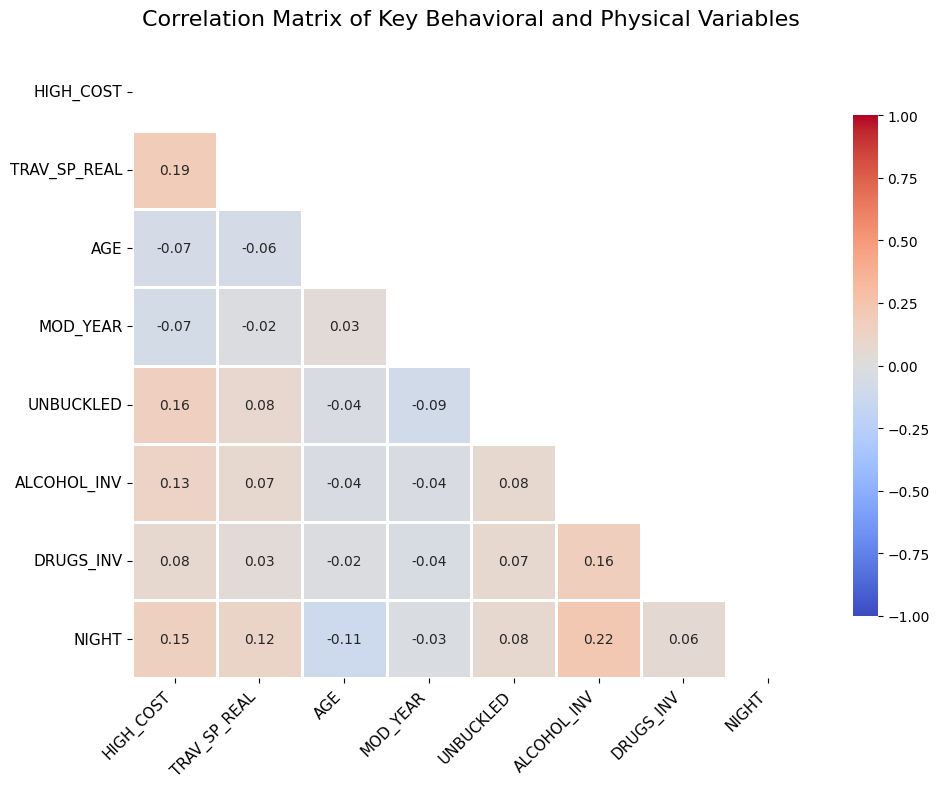

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# PROFESSIONAL CORRELATION MATRIX (For your report)
# =========================================================

# 1. Select only the core variables that drive your hypotheses
core_cols = [
    'HIGH_COST', 
    'TRAV_SP_REAL', 
    'AGE', 
    'MOD_YEAR',
    'UNBUCKLED', 
    'ALCOHOL_INV', 
    'DRUGS_INV', 
    'NIGHT'
]

# Calculate the correlation matrix
corr = v[core_cols].corr()

# 2. Create a "mask" to hide the upper triangle
# This prevents duplicate squares and makes it look like a professional academic paper
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Set up the visualization
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
sns.heatmap(
    corr, 
    mask=mask,               # Applies the triangle mask
    annot=True,              # Prints the exact correlation numbers
    fmt=".2f",               # Rounds to 2 decimal places
    cmap='coolwarm',         # Blue for negative, Red for positive
    vmin=-1, vmax=1,         # Locks the scale from -1 to 1
    center=0,
    linewidths=1,            # Adds clean white lines between squares
    cbar_kws={"shrink": .8}  # Makes the colorbar fit nicely
)

# 5. Formatting the text and layout
plt.title("Correlation Matrix of Key Behavioral and Physical Variables", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

In [5]:
# 1. Build a "Null Model" (A model with NO variables, just the intercept '1')
print("Fitting Null Model...")
null_model = smf.glm(
    formula="HIGH_COST ~ 1", 
    data=v, 
    family=sm.families.Binomial(), 
    freq_weights=v["W"]
).fit()

# 2. Extract AIC from both models
# (Assuming your main model is saved as 'model_final')
aic_null = null_model.aic
aic_final = m_bin.aic

print("\n--- AIC Comparison ---")
print(f"Null Model AIC:  {aic_null:,.2f}")
print(f"Final Model AIC: {aic_final:,.2f}")

# Calculate the difference
aic_diff = aic_null - aic_final
print(f"\nDifference: {aic_diff:,.2f}")


Fitting Null Model...

--- AIC Comparison ---
Null Model AIC:  13,437,492.21
Final Model AIC: 11,397,173.63

Difference: 2,040,318.58



--- Generating ROC Curve & AUC ---


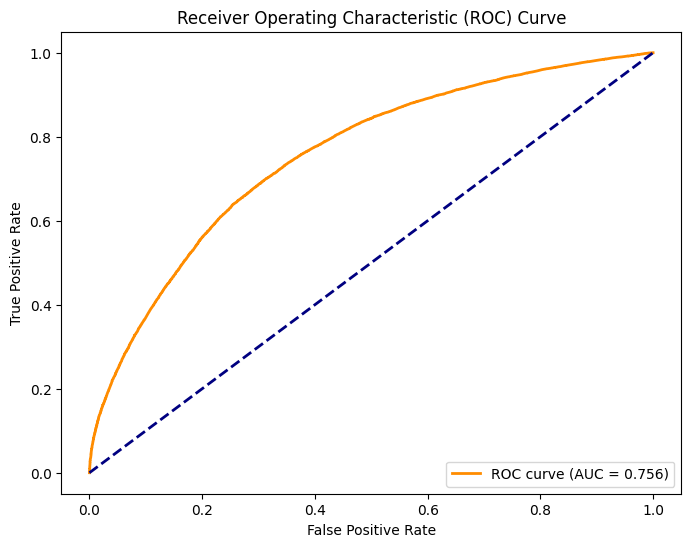

In [6]:
from sklearn.metrics import roc_curve, auc

# =========================================================
# 2. PREDICTIVE POWER (ROC / AUC)
# =========================================================
print("\n--- Generating ROC Curve & AUC ---")

# FIX: We pass the original dataframe 'v' instead of 'X_mat'
v['predicted_prob'] = m_bin.predict(v)

# Calculate False Positive Rate, True Positive Rate, and Area Under Curve
fpr, tpr, thresholds = roc_curve(v['HIGH_COST'], v['predicted_prob'], sample_weight=v['W'])
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


--- Checking for Extreme Outliers ---
Number of highly influential outlier points (D > 0.5): 12 out of 82731
Percentage of data classified as outliers: 0.0145%


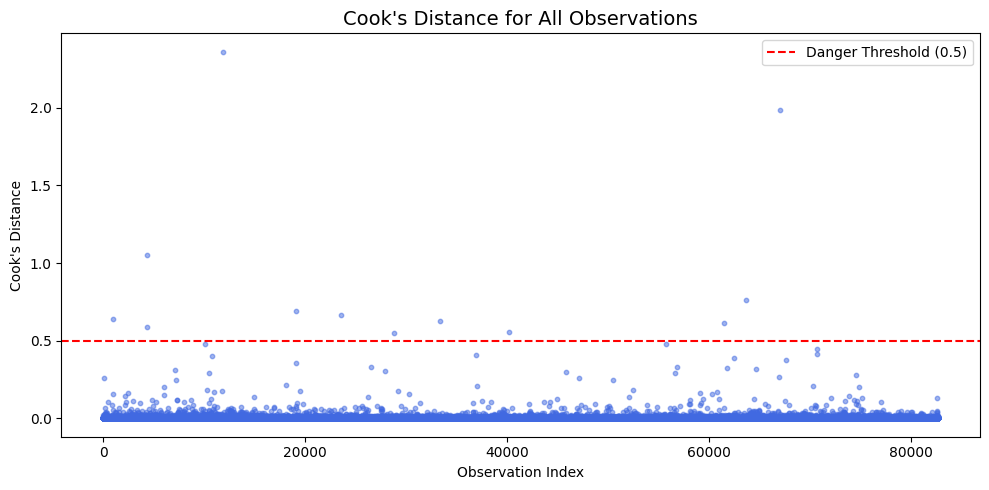

The absolute highest Cook's distance in the dataset is: 2.36176


In [7]:
print("\n--- Checking for Extreme Outliers ---")

# Get the influence measures from the model
influence = m_bin.get_influence()
cooks_d = influence.cooks_distance[0]

# For large N datasets, we use an absolute threshold of 0.5.
absolute_threshold = 0.5

outliers = np.sum(cooks_d > absolute_threshold)
print(f"Number of highly influential outlier points (D > 0.5): {outliers} out of {len(v)}")
print(f"Percentage of data classified as outliers: {(outliers/len(v))*100:.4f}%")

# Plot the Cook's Distances to visually prove the data is safe
plt.figure(figsize=(10, 5))
plt.scatter(range(len(cooks_d)), cooks_d, alpha=0.5, s=10, color='royalblue')
plt.axhline(y=absolute_threshold, color='red', linestyle='--', label='Danger Threshold (0.5)')
plt.title("Cook's Distance for All Observations", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.tight_layout()
plt.show()

# Print the maximum Cook's distance just to be sure
print(f"The absolute highest Cook's distance in the dataset is: {np.max(cooks_d):.5f}")